In [30]:
from ihp import PDK
from ihp.cells.resistors import rhigh
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

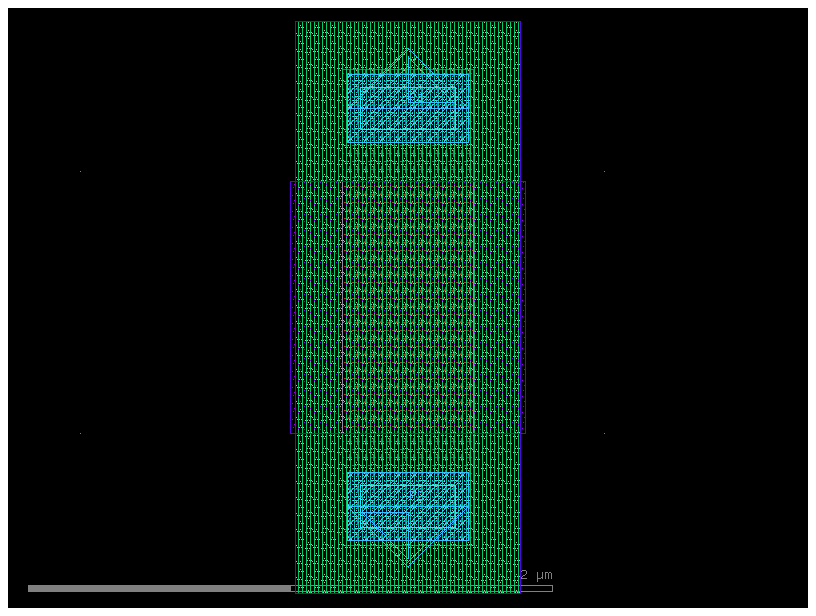

In [31]:
c = rhigh()

keep_layers = [
    (128, 0),  # PolyResdrawing  
    (8, 0),    # Metal1drawing
    (8, 2),    # Metal1pin
    #(52, 0),   # HeatResdrawing 
    #(5, 0),    # GatPolydrawing 
    #(6, 0),    # Contdrawing 
]

cc = c.extract(layers=keep_layers)
cc.add_ports(c.ports)

c.draw_ports()
c.plot()

We remove the HeatResdrawing, GatPolydrawing and Contdrawing layers, since otherwise mesh generation produces the following error:
```
Conductor volume 1 on poly invalidated by dedup
Conductor volume 2 on poly invalidated by dedup
Conductor volume 4 on heatres invalidated by dedup
Error   : Invalid boundary mesh (overlapping facets) on surface 29 surface 93
---------------------------------------------------------------------------
Exception                                 Traceback (most recent call last)
/tmp/ipykernel_749577/2082352375.py in ?()
      1 # TODO: investigate why Z dimension is much larger than expected.
----> 2 sim.mesh(preset="graded",refined_mesh_size=0.2)

~/projects/gsim/src/gsim/palace/driven.py in ?(self, preset, refined_mesh_size, max_mesh_size, margin, airbox_margin, fmax, planar_conductors, show_gui, model_name, verbose)
    668         # Extract ports
    669         palace_ports = extract_ports(component, stack)
    670 
    671         # Generate mesh (config is written separately by simulate() or write_config())
--> 672         return self._generate_mesh_internal(
    673             output_dir=output_dir,
    674             mesh_config=mesh_config,
    675             ports=palace_ports,

~/projects/gsim/src/gsim/palace/driven.py in ?(self, output_dir, mesh_config, ports, driven_config, model_name, verbose, write_config)
    467 
    468         if verbose:
    469             logger.info("Generating mesh in %s", output_dir)
    470 
--> 471         mesh_result = generate_mesh(
    472             component=component,
    473             stack=stack,
    474             ports=ports,

~/projects/gsim/src/gsim/palace/mesh/pipeline.py in ?(component, stack, ports, output_dir, config, model_name, driven_config, write_config, pec_blocks)
    205 
    206     output_dir = Path(output_dir)
    207 
    208     # Use new generator
--> 209     result = gen_mesh(
    210         component=component,
    211         stack=stack,
    212         ports=ports,

~/projects/gsim/src/gsim/palace/mesh/generator.py in ?(component, stack, ports, output_dir, model_name, refined_mesh_size, max_mesh_size, margin, air_margin, fmax, show_gui, driven_config, write_config, planar_conductors, refine_from_curves, pec_blocks, merge_via_distance)
    293             )
    294 
    295     finally:
    296         gmsh.clear()
--> 297         gmsh.finalize()
    298 
    299     # Build result (store groups for deferred config generation)
    300     result = MeshResult(

~/projects/gsim/.venv/lib/python3.12/site-packages/gmsh.py in ?(dim)
   2185             lib.gmshModelMeshGenerate(
   2186                 c_int(dim),
   2187                 byref(ierr))
   2188             if ierr.value != 0:
-> 2189                 raise Exception(logger.getLastError())

Exception: Invalid boundary mesh (overlapping facets) on surface 29 surface 93
```

In [32]:
# Checking the port layers.
cc.ports

["Port(self.name='P1', self.width=460, trans=r90 *1 0.25,1.24, layer=Metal1pin (8/2), port_type=electrical)", "Port(self.name='P2', self.width=460, trans=r270 *1 0.25,-0.28, layer=Metal1pin (8/2), port_type=electrical)"]

In [33]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-rhigh")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=5.0)

sim.add_port("P1",layer="metal1")
sim.add_port("P2",layer="metal1")

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [34]:
# TODO: investigate why Z dimension is much larger than expected.
sim.mesh(preset="graded",refined_mesh_size=0.2)

Mesh Summary
Dimensions: 100.5 x 101.8 x 23.3 µm
Nodes:      449
Elements:   3,117
Tetrahedra: 2,343
Edge length: 0.08 - 53.96 µm
Quality:    0.563 (min: 0.001)
SICN:       0.607 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (11):
  - metal1_xy [4]
  - metal1_z [5]
  - polyres_xy [6]
  - polyres_z [7]
  - P1 [8]
  - P2 [9]
  - SiO2__None [10]
  - SiO2__passive [11]
  - passive__None [12]
  - air__passive [13]
  - air__None [14]
----------------------------------------
Mesh:   runs/palace-sim-rhigh/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 03:29:58.994 ( 461.300s) [    76BD289FE080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 03:29:59.013 ( 461.319s) [    76BD289FE080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 03:29:59.918 ( 462.224s) [    76BD289FE080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


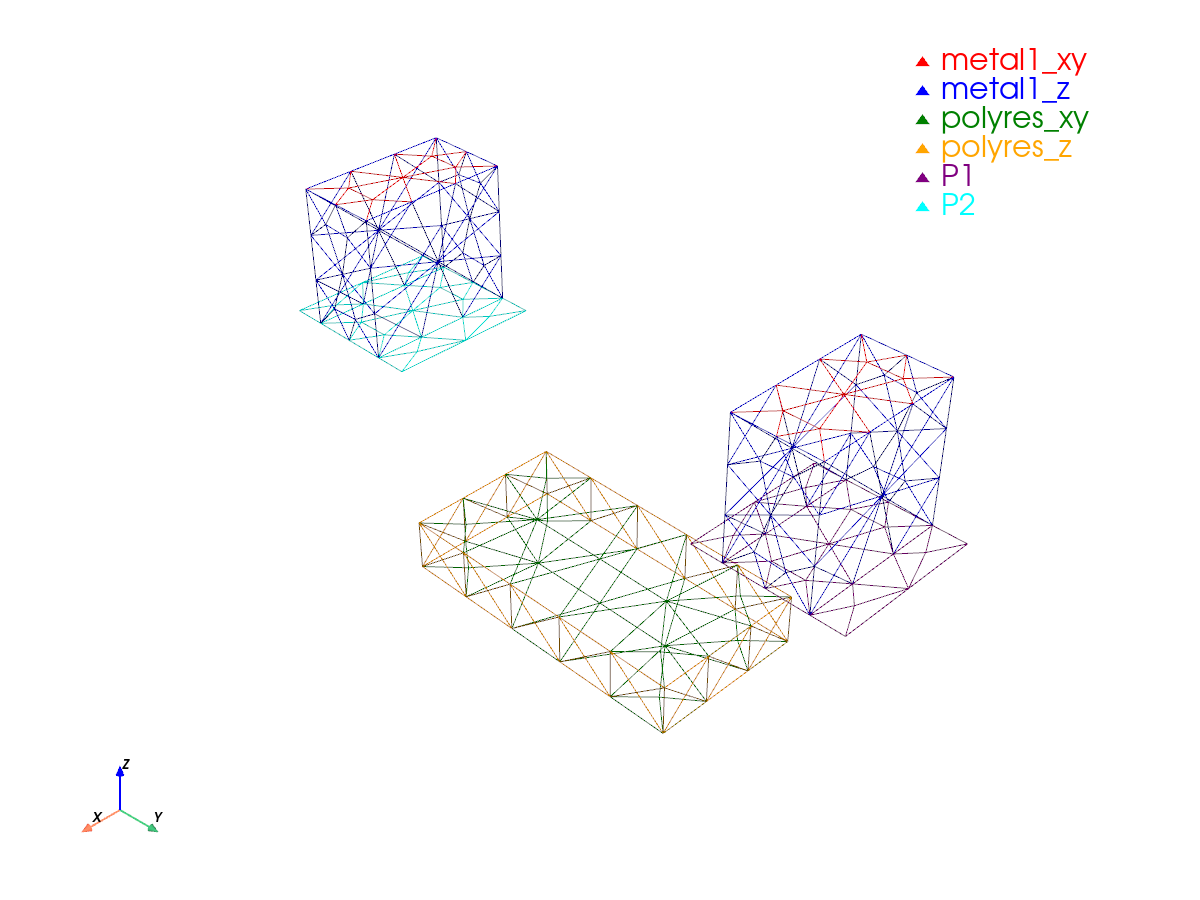

In [35]:
sim.plot_mesh(show_groups=["metal","P","poly","heatres"],interactive=False)

In [36]:
results = sim.run(parent_dir="runs")

  palace-6dc18e03  completed  0m 17s
Extracting results.tar.gz...
Downloaded 11 files to runs/sim-data-palace-6dc18e03


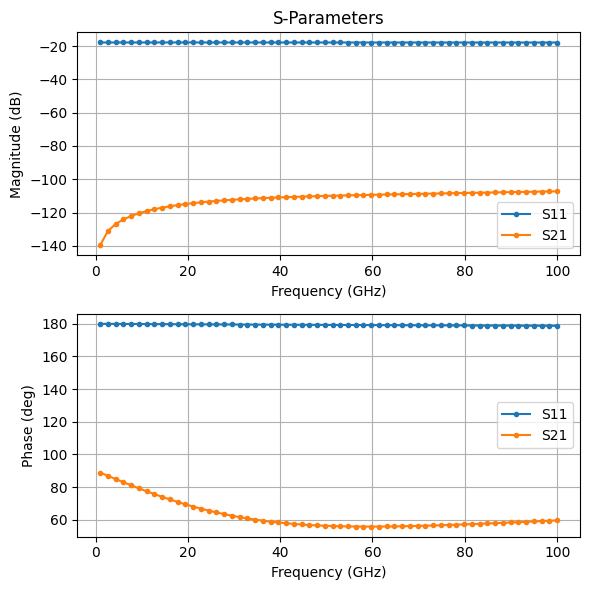

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()